In [1]:
import os

print(os.getcwd())

C:\Users\HP\OneDrive\Desktop\Stock-Anlysis\notebook


In [2]:
!pip install yfinance pandas numpy matplotlib seaborn scikit-learn mysql-connector-python

  Obtaining dependency information for seaborn from https://files.pythonhosted.org/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac01809010ba88f6d5/seaborn-0.13.2-py3-none-any.whl.metadata
  Obtaining dependency information for scikit-learn from https://files.pythonhosted.org/packages/83/a4/c8e67227c680e2259c8864ae72ff48b06e16a6f51253a22167aa02a8aa4e/scikit_learn-1.9.0-cp312-cp312-win_amd64.whl.metadata
  Obtaining dependency information for mysql-connector-python from https://files.pythonhosted.org/packages/ff/01/07efeb3e3fc730f945af40ddf1f4c879c13945b193a94eba8e642c0d4176/mysql_connector_python-26.7.0-py2.py3-none-any.whl.metadata
  Obtaining dependency information for scipy>=1.10.0 from https://files.pythonhosted.org/packages/2b/54/9a9edb45345bd6744da5ddfb6628e5d5185920494c6a67ec45b6381004cb/scipy-1.18.0-cp312-cp312-win_amd64.whl.metadata
     ---------------------------------------- 0.0/61.1 kB ? eta -:--:--
     ------------------- ------------------ 30.7/61.1 kB 660.6 


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
# Download 5 years of Apple stock data
df = yf.download("AAPL", period="5y")

# Display the first 5 rows
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2021-08-12,145.222992,145.379055,142.248107,142.589493,72282600
2021-08-13,145.427826,145.759449,144.618266,145.301023,59375000
2021-08-16,147.398087,147.466370,142.862617,144.881627,103296000
2021-08-17,146.490997,147.944291,145.418083,146.530006,92229700
2021-08-18,142.755325,147.007944,142.550491,146.110605,86326000


In [6]:
df.shape

(1254, 5)

In [7]:
df.columns

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])

In [8]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1254 entries, 2021-08-12 to 2026-08-11
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1254 non-null   float64
 1   (High, AAPL)    1254 non-null   float64
 2   (Low, AAPL)     1254 non-null   float64
 3   (Open, AAPL)    1254 non-null   float64
 4   (Volume, AAPL)  1254 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.8 KB


In [9]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1254.000000,1254.000000,1254.000000,1254.000000,1.254000e+03
mean,197.647121,199.619508,195.476996,197.429373,6.466398e+07
std,47.829673,48.210334,47.373297,47.750263,2.859671e+07
min,122.827614,125.529389,121.992513,123.800267,1.791060e+07
25%,159.981510,161.869754,157.531670,159.753009,4.548928e+07
50%,185.808609,187.237273,184.653289,185.825622,5.629255e+07
75%,229.462990,231.409098,226.809237,229.173477,7.639795e+07
max,339.786926,344.273097,337.059318,339.736982,3.186799e+08


In [10]:
df.isnull().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df = df.drop_duplicates()

In [13]:
df.shape

(1254, 5)

In [14]:
df.to_csv("../data/stock_data.csv", index=True)

print("Dataset saved successfully!")

Dataset saved successfully!


In [15]:
import mysql.connector

In [16]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Muskanss@12",
    database="stock_analysis"
)

cursor = conn.cursor()

print("Connected to MySQL successfully!")

Connected to MySQL successfully!


In [17]:
print(df.columns)

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])


In [18]:
df.columns = df.columns.get_level_values(0)

df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2021-08-12,145.223038,145.379101,142.248152,142.589538,72282600
2021-08-13,145.427841,145.759464,144.618281,145.301038,59375000
2021-08-16,147.398087,147.466370,142.862617,144.881627,103296000
2021-08-17,146.490982,147.944275,145.418068,146.529990,92229700
2021-08-18,142.755310,147.007929,142.550476,146.110589,86326000


In [19]:
# Flatten the MultiIndex columns
df.columns = [col[0] for col in df.columns]

# Convert Date index to a normal column
df.reset_index(inplace=True)

# Display first 5 rows
df.head()

,Date,C,H,L,O,V
0,2021-08-12,145.223038,145.379101,142.248152,142.589538,72282600
1,2021-08-13,145.427841,145.759464,144.618281,145.301038,59375000
2,2021-08-16,147.398087,147.466370,142.862617,144.881627,103296000
3,2021-08-17,146.490982,147.944275,145.418068,146.529990,92229700
4,2021-08-18,142.755310,147.007929,142.550476,146.110589,86326000


In [21]:
query = """
INSERT INTO stock_prices
(date, open_price, high_price, low_price, close_price, volume)
VALUES (%s, %s, %s, %s, %s, %s)
"""

In [23]:
print(df.columns.tolist())

['Date', 'C', 'H', 'L', 'O', 'V']


In [24]:
df.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

print(df.columns)
df.head()

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')


,Date,Close,High,Low,Open,Volume
0,2021-08-12,145.223038,145.379101,142.248152,142.589538,72282600
1,2021-08-13,145.427841,145.759464,144.618281,145.301038,59375000
2,2021-08-16,147.398087,147.466370,142.862617,144.881627,103296000
3,2021-08-17,146.490982,147.944275,145.418068,146.529990,92229700
4,2021-08-18,142.755310,147.007929,142.550476,146.110589,86326000


In [25]:
query = """
INSERT INTO stock_prices
(date, open_price, high_price, low_price, close_price, volume)
VALUES (%s, %s, %s, %s, %s, %s)
"""

for index, row in df.iterrows():
    cursor.execute(query, (
        row['Date'],
        float(row['Open']),
        float(row['High']),
        float(row['Low']),
        float(row['Close']),
        int(row['Volume'])
    ))

conn.commit()

print("Data inserted successfully!")

Data inserted successfully!


In [27]:
import yfinance as yf
import pandas as pd

In [28]:
stocks = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA"]

all_data = []

for stock in stocks:
    data = yf.download(stock, period="5y")
    data["Company"] = stock
    all_data.append(data)

print("Data downloaded successfully!")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Data downloaded successfully!


In [29]:
df = pd.concat(all_data)

df.head()

Price,Close,High,Low,Open,Volume,Company,Close,High,Low,Open,...,Close,High,Low,Open,Volume,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,MSFT,MSFT,MSFT,MSFT,...,AMZN,AMZN,AMZN,AMZN,AMZN,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,,,,,,,,,,,,,,,,,
2021-08-12,145.223022,145.379085,142.248137,142.589523,72282600.0,AAPL,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-08-13,145.427856,145.759479,144.618297,145.301053,59375000.0,AAPL,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-08-16,147.398087,147.466370,142.862617,144.881627,103296000.0,AAPL,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-08-17,146.490952,147.944245,145.418038,146.529960,92229700.0,AAPL,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-08-18,142.755325,147.007944,142.550491,146.110605,86326000.0,AAPL,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
df.shape

(6270, 26)

In [31]:
print(df.columns)

MultiIndex([(  'Close',  'AAPL'),
            (   'High',  'AAPL'),
            (    'Low',  'AAPL'),
            (   'Open',  'AAPL'),
            ( 'Volume',  'AAPL'),
            ('Company',      ''),
            (  'Close',  'MSFT'),
            (   'High',  'MSFT'),
            (    'Low',  'MSFT'),
            (   'Open',  'MSFT'),
            ( 'Volume',  'MSFT'),
            (  'Close', 'GOOGL'),
            (   'High', 'GOOGL'),
            (    'Low', 'GOOGL'),
            (   'Open', 'GOOGL'),
            ( 'Volume', 'GOOGL'),
            (  'Close',  'AMZN'),
            (   'High',  'AMZN'),
            (    'Low',  'AMZN'),
            (   'Open',  'AMZN'),
            ( 'Volume',  'AMZN'),
            (  'Close',  'TSLA'),
            (   'High',  'TSLA'),
            (    'Low',  'TSLA'),
            (   'Open',  'TSLA'),
            ( 'Volume',  'TSLA')],
           names=['Price', 'Ticker'])


In [32]:
print(df.columns)

MultiIndex([(  'Close',  'AAPL'),
            (   'High',  'AAPL'),
            (    'Low',  'AAPL'),
            (   'Open',  'AAPL'),
            ( 'Volume',  'AAPL'),
            ('Company',      ''),
            (  'Close',  'MSFT'),
            (   'High',  'MSFT'),
            (    'Low',  'MSFT'),
            (   'Open',  'MSFT'),
            ( 'Volume',  'MSFT'),
            (  'Close', 'GOOGL'),
            (   'High', 'GOOGL'),
            (    'Low', 'GOOGL'),
            (   'Open', 'GOOGL'),
            ( 'Volume', 'GOOGL'),
            (  'Close',  'AMZN'),
            (   'High',  'AMZN'),
            (    'Low',  'AMZN'),
            (   'Open',  'AMZN'),
            ( 'Volume',  'AMZN'),
            (  'Close',  'TSLA'),
            (   'High',  'TSLA'),
            (    'Low',  'TSLA'),
            (   'Open',  'TSLA'),
            ( 'Volume',  'TSLA')],
           names=['Price', 'Ticker'])


In [1]:
import yfinance as yf
import pandas as pd

stocks = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA"]

all_data = []

for stock in stocks:
    # Download one stock
    data = yf.download(stock, period="5y", auto_adjust=False)

    # Flatten MultiIndex columns if present
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    # Make Date a normal column
    data.reset_index(inplace=True)

    # Add company name
    data["Company"] = stock

    # Keep only required columns
    data = data[["Date", "Company", "Open", "High", "Low", "Close", "Volume"]]

    # Store this company's data
    all_data.append(data)

# Combine all companies vertically
df = pd.concat(all_data, ignore_index=True)

print(df.shape)
print(df.columns)
df.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

(6270, 7)
Index(['Date', 'Company', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='str', name='Price')


Price,Date,Company,Open,High,Low,Close,Volume
0,2021-08-12,AAPL,146.190002,149.050003,145.839996,148.889999,72282600
1,2021-08-13,AAPL,148.970001,149.440002,148.270004,149.100006,59375000
2,2021-08-16,AAPL,148.539993,151.190002,146.470001,151.119995,103296000
3,2021-08-17,AAPL,150.229996,151.679993,149.089996,150.190002,92229700
4,2021-08-18,AAPL,149.800003,150.720001,146.149994,146.360001,86326000


In [2]:
print(df.columns)

Index(['Date', 'Company', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='str', name='Price')


In [3]:
query = """
INSERT INTO stock_prices
(company, date, open_price, high_price, low_price, close_price, volume)
VALUES (%s, %s, %s, %s, %s, %s, %s)
"""

In [5]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Muskanss@12",   # Replace with your MySQL password
    database="stock_analysis"
)

cursor = conn.cursor()

print("Connected Successfully!")

Connected Successfully!


In [6]:
query = """
INSERT INTO stock_prices
(company, date, open_price, high_price, low_price, close_price, volume)
VALUES (%s, %s, %s, %s, %s, %s, %s)
"""

In [7]:
for index, row in df.iterrows():
    cursor.execute(query, (
        row["Company"],
        row["Date"],
        float(row["Open"]),
        float(row["High"]),
        float(row["Low"]),
        float(row["Close"]),
        int(row["Volume"])
    ))

conn.commit()

print("All records inserted successfully!")

All records inserted successfully!


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6270 entries, 0 to 6269
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype        
---  ------   --------------  -----        
 0   Date     6270 non-null   datetime64[s]
 1   Company  6270 non-null   str          
 2   Open     6270 non-null   float64      
 3   High     6270 non-null   float64      
 4   Low      6270 non-null   float64      
 5   Close    6270 non-null   float64      
 6   Volume   6270 non-null   int64        
dtypes: datetime64[s](1), float64(4), int64(1), str(1)
memory usage: 343.0 KB


In [10]:
df.describe()

Price,Date,Open,High,Low,Close,Volume
count,6270,6270.000000,6270.000000,6270.000000,6270.000000,6.270000e+03
mean,2024-02-09 05:26:07,239.951934,243.170012,236.673376,240.000797,5.490710e+07
min,2021-08-12 00:00:00,82.800003,83.480003,81.430000,81.820000,5.855900e+06
25%,2022-11-08 00:00:00,160.927494,163.181747,158.915001,161.223129,2.883255e+07
50%,2024-02-08 12:00:00,218.564995,221.764999,214.696671,218.485001,4.492165e+07
75%,2025-05-12 00:00:00,304.790833,309.630005,300.923325,305.410004,6.988265e+07
max,2026-08-11 00:00:00,555.229980,555.450012,540.770020,542.070007,3.186799e+08
std,NaN,103.561973,104.756994,102.211094,103.508716,3.611652e+07


In [11]:
df.isnull().sum()

Price
Date       0
Company    0
Open       0
High       0
Low        0
Close      0
Volume     0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df["Company"].value_counts()

Company
AAPL     1254
MSFT     1254
GOOGL    1254
AMZN     1254
TSLA     1254
Name: count, dtype: int64

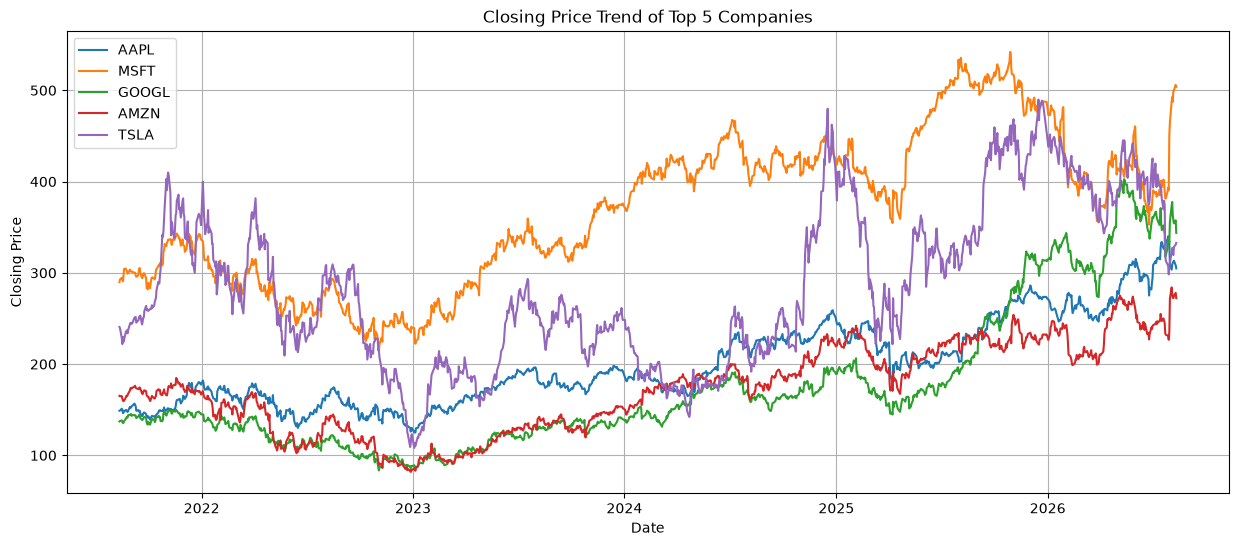

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

for company in df["Company"].unique():
    company_data = df[df["Company"] == company]
    plt.plot(company_data["Date"], company_data["Close"], label=company)

plt.title("Closing Price Trend of Top 5 Companies")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)

plt.show()

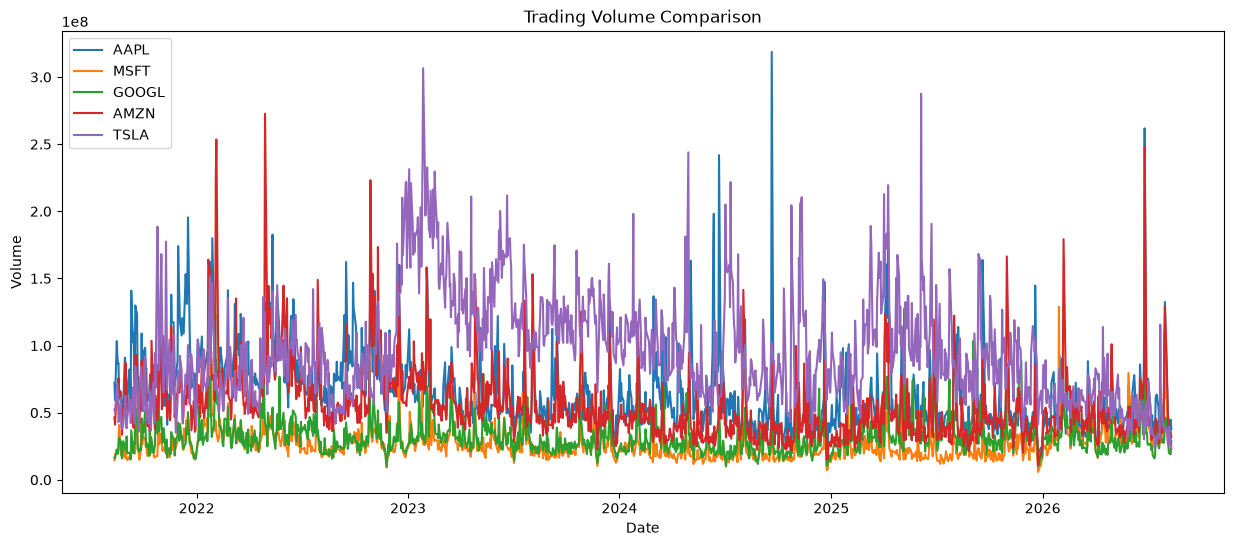

In [15]:
plt.figure(figsize=(15,6))

for company in df["Company"].unique():
    company_data = df[df["Company"] == company]
    plt.plot(company_data["Date"], company_data["Volume"], label=company)

plt.title("Trading Volume Comparison")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.legend()

plt.show()

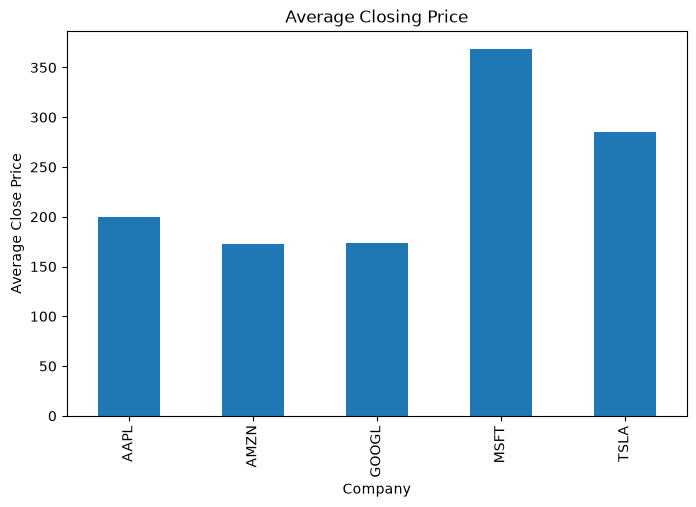

In [16]:
average_price = df.groupby("Company")["Close"].mean()

average_price.plot(kind="bar", figsize=(8,5))

plt.title("Average Closing Price")
plt.xlabel("Company")
plt.ylabel("Average Close Price")

plt.show()

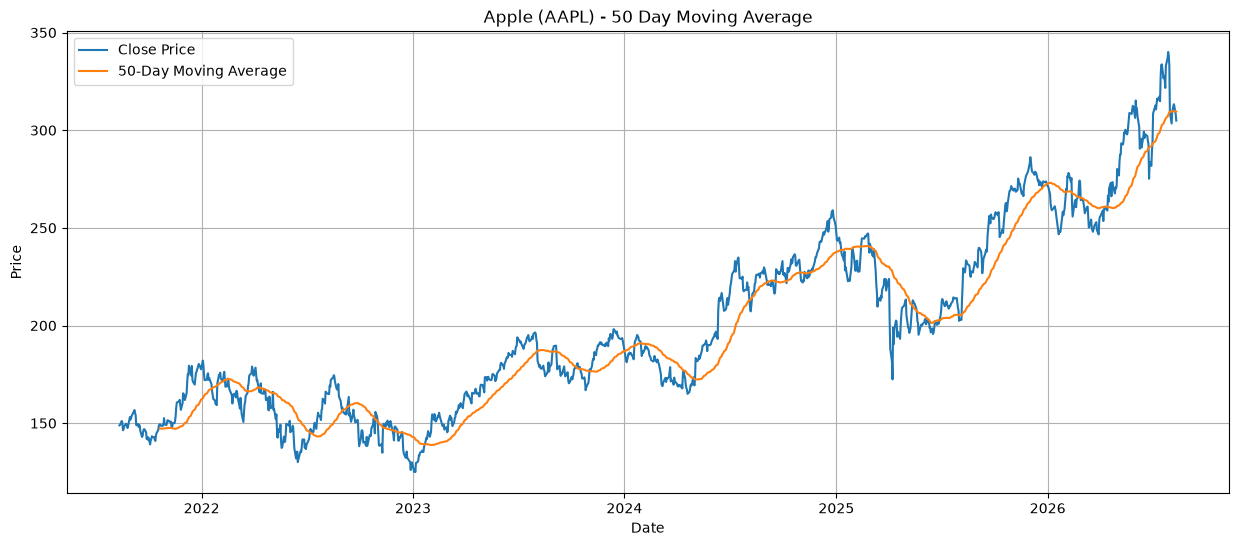

In [17]:
import matplotlib.pyplot as plt

# Apple data
aapl = df[df["Company"] == "AAPL"].copy()

# Calculate 50-day Moving Average
aapl["MA50"] = aapl["Close"].rolling(window=50).mean()

plt.figure(figsize=(15,6))
plt.plot(aapl["Date"], aapl["Close"], label="Close Price")
plt.plot(aapl["Date"], aapl["MA50"], label="50-Day Moving Average")

plt.title("Apple (AAPL) - 50 Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)

plt.show()

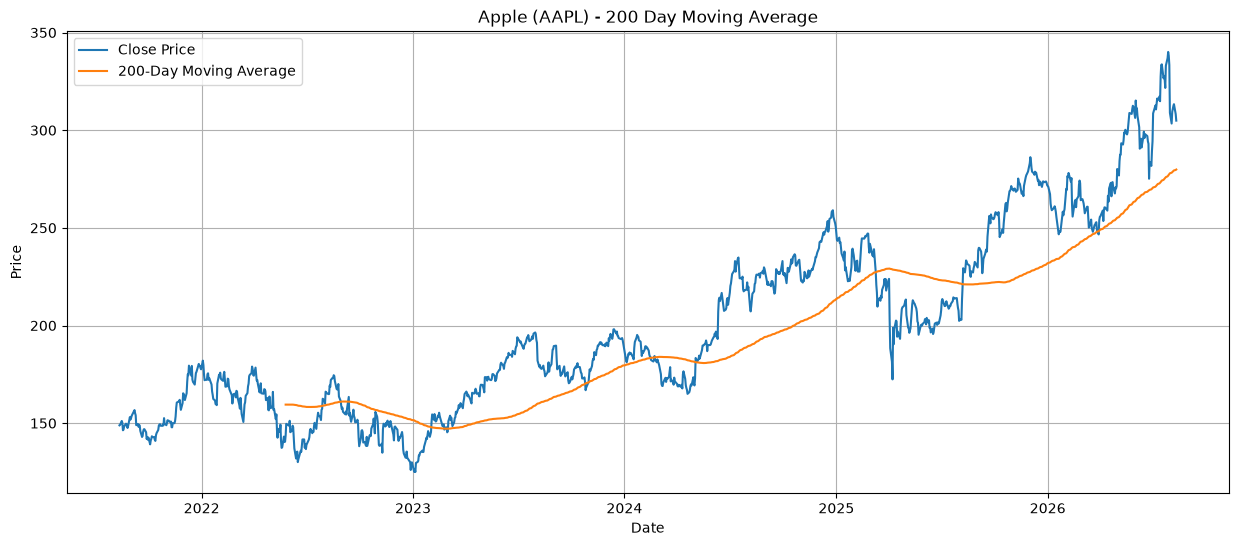

In [18]:
aapl["MA200"] = aapl["Close"].rolling(window=200).mean()

plt.figure(figsize=(15,6))

plt.plot(aapl["Date"], aapl["Close"], label="Close Price")
plt.plot(aapl["Date"], aapl["MA200"], label="200-Day Moving Average")

plt.title("Apple (AAPL) - 200 Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)

plt.show()

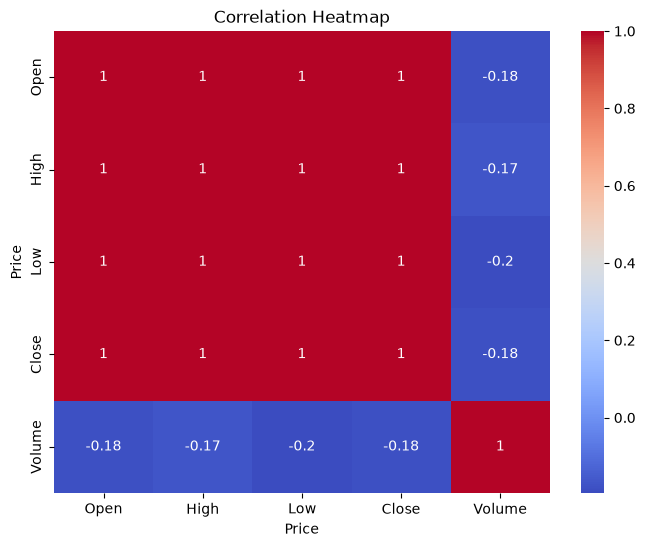

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    df[["Open", "High", "Low", "Close", "Volume"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

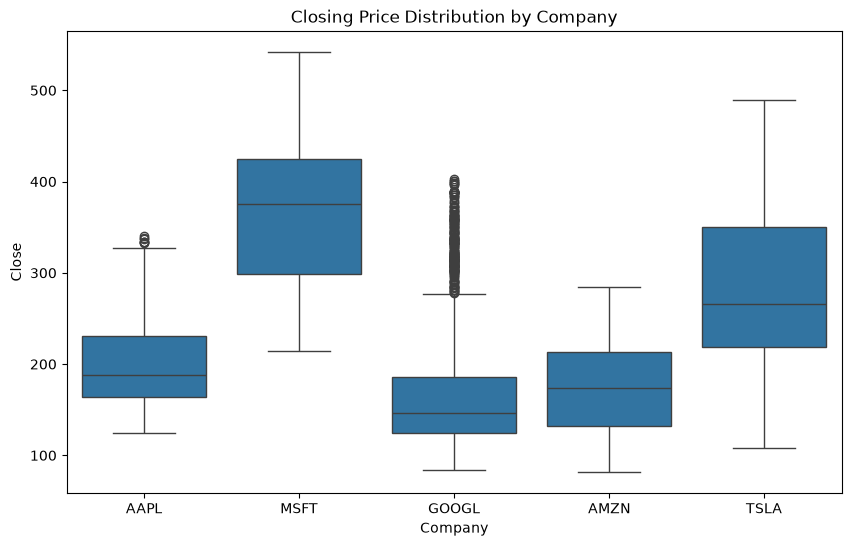

In [20]:
plt.figure(figsize=(10,6))

sns.boxplot(x="Company", y="Close", data=df)

plt.title("Closing Price Distribution by Company")

plt.show()

In [22]:
df = df.sort_values(["Company", "Date"])

df["Daily_Return"] = df.groupby("Company")["Close"].pct_change()

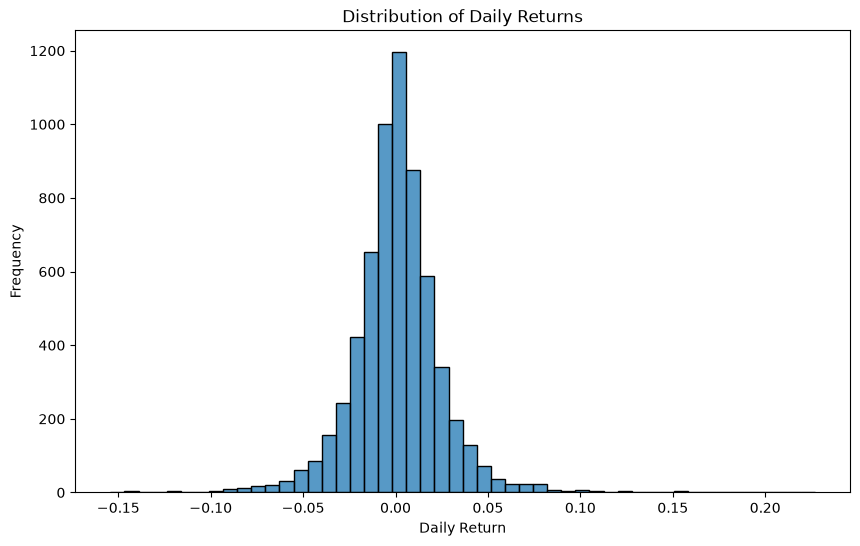

In [23]:
plt.figure(figsize=(10,6))

sns.histplot(df["Daily_Return"].dropna(), bins=50)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [25]:
X = df[["Open", "High", "Low", "Volume"]]

y = df["Close"]

print(X.head())

print(y.head())

Price        Open        High         Low     Volume
0      146.190002  149.050003  145.839996   72282600
1      148.970001  149.440002  148.270004   59375000
2      148.539993  151.190002  146.470001  103296000
3      150.229996  151.679993  149.089996   92229700
4      149.800003  150.720001  146.149994   86326000
0    148.889999
1    149.100006
2    151.119995
3    150.190002
4    146.360001
Name: Close, dtype: float64


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data :", X_train.shape)
print("Testing Data  :", X_test.shape)

Training Data : (5016, 4)
Testing Data  : (1254, 4)


In [27]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [28]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[141.84019542 168.19917376 241.37394267 329.05709595 144.89166668
 430.52602538 271.44439361 365.09375638 466.10080537 244.16996071]


In [29]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error :", mae)
print("Mean Squared Error  :", mse)
print("Root Mean Squared Error :", rmse)
print("R2 Score :", r2)

Mean Absolute Error : 2.283286140369681
Mean Squared Error  : 12.563900510587782
Root Mean Squared Error : 3.5445592829839625
R2 Score : 0.9988483142161584


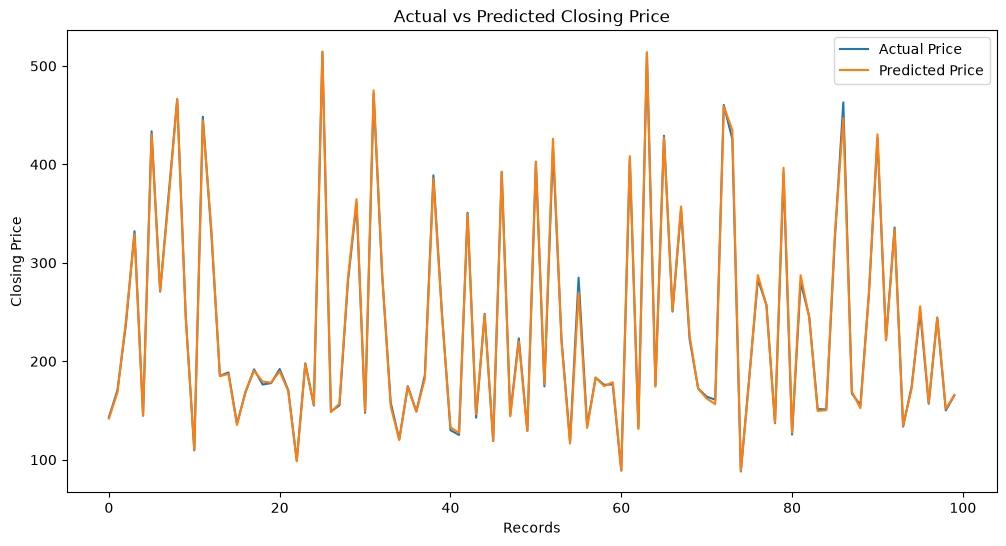

In [30]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values[:100], label="Actual Price")
plt.plot(y_pred[:100], label="Predicted Price")

plt.title("Actual vs Predicted Closing Price")

plt.xlabel("Records")
plt.ylabel("Closing Price")

plt.legend()

plt.show()

In [31]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

importance

,Feature,Coefficient
0,Open,3.333602e-01
1,High,3.379972e-01
2,Low,3.281873e-01
3,Volume,2.766769e-09


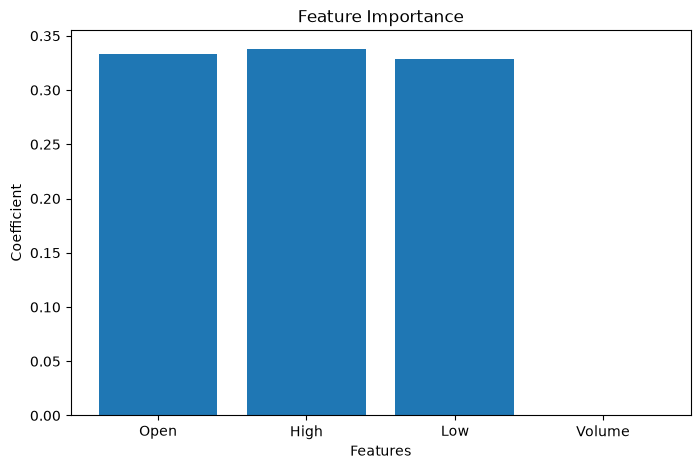

In [32]:
plt.figure(figsize=(8,5))

plt.bar(importance["Feature"], importance["Coefficient"])

plt.title("Feature Importance")

plt.xlabel("Features")
plt.ylabel("Coefficient")

plt.show()

In [33]:
import logging
import os

# Create logs folder if it doesn't exist
os.makedirs("../logs", exist_ok=True)

logging.basicConfig(
    filename="../logs/project.log",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    force=True      # Important in Jupyter Notebook
)

logging.info("Project Started")
logging.info("Dataset Loaded Successfully")
logging.info("Data Inserted into MySQL")
logging.info("EDA Completed")
logging.info("Visualizations Completed")
logging.info("Machine Learning Model Trained")

print("Logging completed successfully!")

Logging completed successfully!


In [35]:
try:
    data = pd.read_csv("../data/stock_data.csv")
    print("Dataset loaded successfully!")

except FileNotFoundError:
    print("Error: Dataset file not found.")

except pd.errors.EmptyDataError:
    print("Error: Dataset is empty.")

except Exception as e:
    print("Unexpected Error:", e)

Dataset loaded successfully!


In [36]:
prediction_df = pd.DataFrame({
    "Actual_Close": y_test.values,
    "Predicted_Close": y_pred
})

prediction_df.head()


,Actual_Close,Predicted_Close
0,143.100006,141.840195
1,170.417007,168.199174
2,238.009995,241.373943
3,332.109985,329.057096
4,144.697495,144.891667


In [37]:
prediction_df.to_csv("../reports/predictions.csv", index=False)

print("Prediction report saved successfully!")

Prediction report saved successfully!


In [38]:
import os

print(os.listdir("../reports"))

['predictions.csv']
